In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("15-gym_crowdedness.csv")

In [3]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
df.tail()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
62179,23,2017-03-18 18:42:28-07:00,67348,5,1,0,61.07,0,1,3,18
62180,21,2017-03-18 18:52:35-07:00,67955,5,1,0,61.07,0,1,3,18
62181,25,2017-03-18 19:02:40-07:00,68560,5,1,0,56.71,0,1,3,19
62182,18,2017-03-18 19:12:47-07:00,69167,5,1,0,56.71,0,1,3,19
62183,23,2017-03-18 19:22:51-07:00,69771,5,1,0,56.71,0,1,3,19


In [5]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [7]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [8]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [10]:
df["date"] = pd.to_datetime(df["date"], utc = True)

In [11]:
df["date"]

0       2015-08-15 00:00:11+00:00
1       2015-08-15 00:20:14+00:00
2       2015-08-15 00:30:15+00:00
3       2015-08-15 00:40:16+00:00
4       2015-08-15 00:50:17+00:00
                   ...           
62179   2017-03-19 01:42:28+00:00
62180   2017-03-19 01:52:35+00:00
62181   2017-03-19 02:02:40+00:00
62182   2017-03-19 02:12:47+00:00
62183   2017-03-19 02:22:51+00:00
Name: date, Length: 62184, dtype: datetime64[ns, UTC]

In [12]:
df["date"].dt.year

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
62179    2017
62180    2017
62181    2017
62182    2017
62183    2017
Name: date, Length: 62184, dtype: int32

In [13]:
df["date"].dt.month

0        8
1        8
2        8
3        8
4        8
        ..
62179    3
62180    3
62181    3
62182    3
62183    3
Name: date, Length: 62184, dtype: int32

In [14]:
df.drop("date", axis=1, inplace=True)

In [15]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,61211,4,0,0,71.76,0,0,8,17
1,45,62414,4,0,0,71.76,0,0,8,17
2,40,63015,4,0,0,71.76,0,0,8,17
3,44,63616,4,0,0,71.76,0,0,8,17
4,45,64217,4,0,0,71.76,0,0,8,17


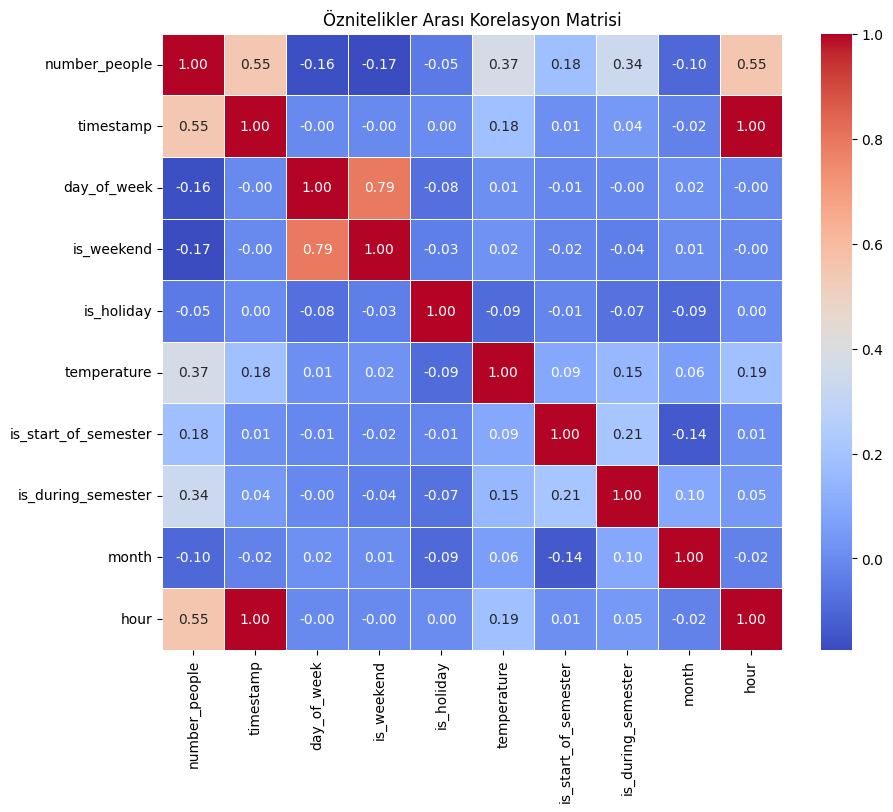

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Öznitelikler Arası Korelasyon Matrisi")
plt.show()

/var/folders/h5/swlzny612n16xym3ymfjfzsh0000gn/T/ipykernel_4922/1908156570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day_of_week", y="number_people", data=df, palette="Set2")


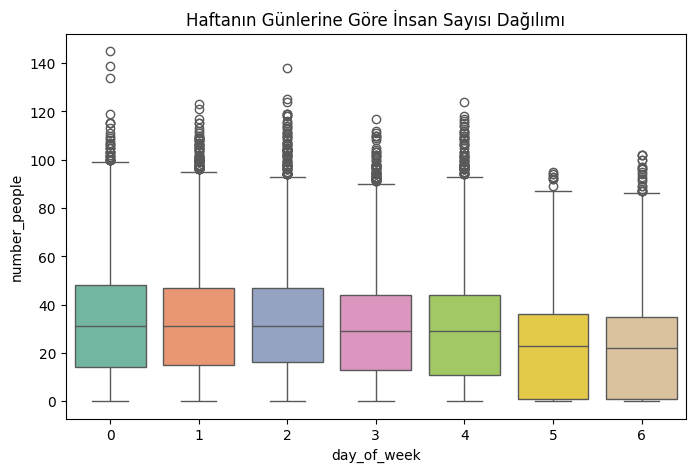

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="day_of_week", y="number_people", data=df, palette="Set2")
plt.title("Haftanın Günlerine Göre İnsan Sayısı Dağılımı")
plt.show()

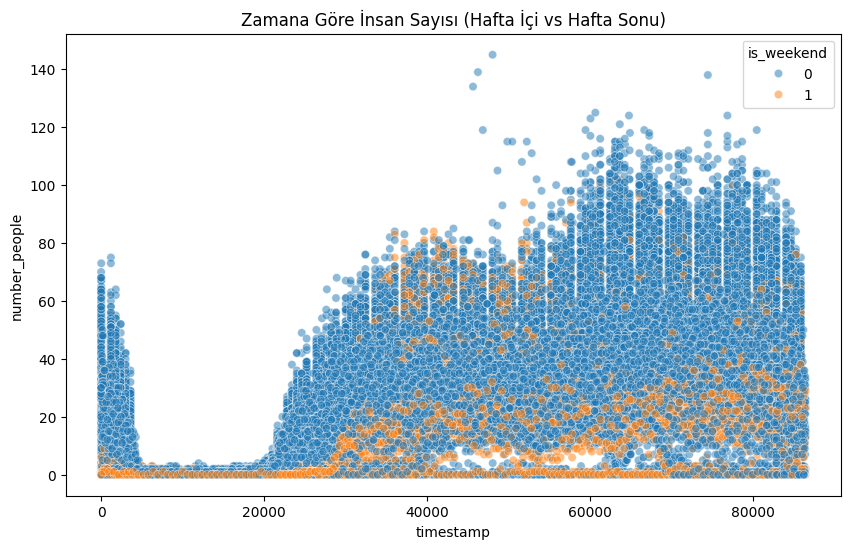

In [18]:
plt.figure(figsize=(10, 6))
# hue parametresi veriyi hafta sonu olup olmamasına göre iki farklı renge böler
sns.scatterplot(x="timestamp", y="number_people", hue="is_weekend", data=df, alpha=0.5)
plt.title("Zamana Göre İnsan Sayısı (Hafta İçi vs Hafta Sonu)")
plt.show()

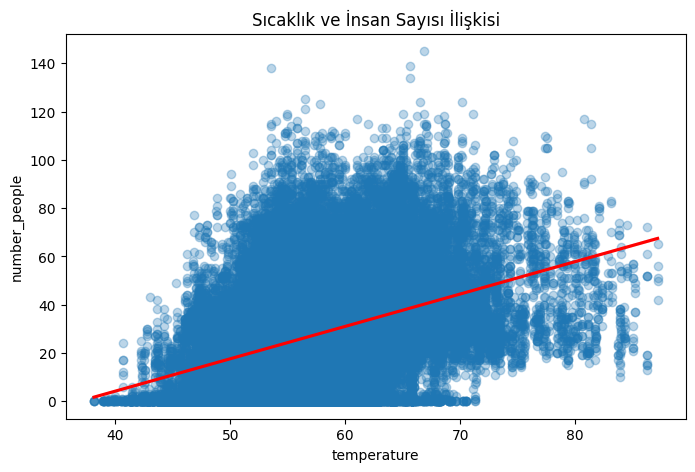

In [19]:
plt.figure(figsize=(8, 5))
# Veri noktalarını çizer ve ortasından en iyi uyan (best-fit) doğruyu geçirir
sns.regplot(x="temperature", y="number_people", data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Sıcaklık ve İnsan Sayısı İlişkisi")
plt.show()

In [20]:
df.corr()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
number_people,1.000000,0.550218,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049
timestamp,0.550218,1.000000,-0.001793,-0.000509,0.002851,0.184849,0.009551,0.044676,-0.023221,0.999077
day_of_week,-0.162062,-0.001793,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914
is_weekend,-0.173958,-0.000509,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517
is_holiday,-0.048249,0.002851,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843
temperature,0.373327,0.184849,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121
is_start_of_semester,0.182683,0.009551,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091
is_during_semester,0.335350,0.044676,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581
month,-0.097854,-0.023221,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624
hour,0.552049,0.999077,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000


In [21]:
df.drop("timestamp", axis=1, inplace=True)

In [22]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,4,0,0,71.76,0,0,8,17
1,45,4,0,0,71.76,0,0,8,17
2,40,4,0,0,71.76,0,0,8,17
3,44,4,0,0,71.76,0,0,8,17
4,45,4,0,0,71.76,0,0,8,17


In [27]:
from sklearn.model_selection import train_test_split
X=df.drop("number_people", axis=1)
y=df["number_people"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 15)

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [32]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor()}

In [35]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])
    print("Evaluation for Training Set")
    print("RMSE: ", model_train_rmse)
    print("mae: ", model_train_mae)
    print("r2: ", model_train_r2)

    print("---------------")
    print(list(models.values())[i])
    print("Evaluation for Training Set")
    print("RMSE: ", model_test_rmse)
    print("mae: ", model_test_mae)
    print("r2: ", model_test_r2)

    print("---------------")

LinearRegression()
Evaluation for Training Set
RMSE:  15.883118308933344
mae:  12.161594381048532
r2:  0.5080363861278016
---------------
LinearRegression()
Evaluation for Training Set
RMSE:  15.946280992932833
mae:  12.151677275046948
r2:  0.511608197834744
---------------
Lasso()
Evaluation for Training Set
RMSE:  16.05417996018521
mae:  12.299391640729938
r2:  0.4973823963533949
---------------
Lasso()
Evaluation for Training Set
RMSE:  16.14284300658442
mae:  12.289006787606725
r2:  0.4994936559913552
---------------
Ridge()
Evaluation for Training Set
RMSE:  15.883118311482958
mae:  12.161596458005883
r2:  0.5080363859698581
---------------
Ridge()
Evaluation for Training Set
RMSE:  15.946283757250121
mae:  12.151677845527946
r2:  0.5116080285074858
---------------
KNeighborsRegressor()
Evaluation for Training Set
RMSE:  5.836206860566118
mae:  3.8829237960461422
r2:  0.9335763410645904
---------------
KNeighborsRegressor()
Evaluation for Training Set
RMSE:  8.03125872363506
mae: 

In [36]:
# hyperparameter tuning

In [38]:
knn_params={"n_neighbors" :[2, 3, 10, 20, 40, 50]}
rf_params = {
    "max_depth": [5, 8, 10, 15, None],
    "max_features": ["sqrt", "log2", 5, 7, 10],
    "min_samples_split": [2, 8, 12, 20],
    "n_estimators": [100, 200, 500, 1000]
}

In [39]:
from sklearn.model_selection import RandomizedSearchCV

In [40]:
randomcv_models = [("KNN", KNeighborsRegressor(), knn_params),
                   ("RF", RandomForestRegressor(), rf_params)]

In [41]:
for name, model, params in randomcv_models:
    randomcv= RandomizedSearchCV(estimator = model, param_distributions = params, n_iter=100, cv=3, n_jobs=-1)
    randomcv.fit(X_train, y_train)
    print("best params for: ", name, randomcv.best_params_)   

/opt/homebrew/lib/python3.14/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best params for:  KNN {'n_neighbors': 2}


/opt/homebrew/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best params for:  RF {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [42]:
# best params for:  KNN {'n_neighbors': 2}
# best params for:  RF {'n_estimators': 500, 
#'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [43]:
models = {
    "K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=2),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=500,
                                           min_samples_split = 2,
                                            max_features = 7, max_depth = None)}

In [44]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])
    print("Evaluation for Training Set")
    print("RMSE: ", model_train_rmse)
    print("mae: ", model_train_mae)
    print("r2: ", model_train_r2)

    print("---------------")
    print(list(models.values())[i])
    print("Evaluation for Training Set")
    print("RMSE: ", model_test_rmse)
    print("mae: ", model_test_mae)
    print("r2: ", model_test_r2)

    print("---------------")

KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
RMSE:  5.525841405483949
mae:  3.5799240962305414
r2:  0.9404532210918106
---------------
KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
RMSE:  7.0327327813854
mae:  4.693972726103178
r2:  0.9050056506437475
---------------
RandomForestRegressor(max_features=7, n_estimators=500)
Evaluation for Training Set
RMSE:  4.757633632028306
mae:  3.2241221747645
r2:  0.9558588714501446
---------------
RandomForestRegressor(max_features=7, n_estimators=500)
Evaluation for Training Set
RMSE:  6.493856291689326
mae:  4.350643138369211
r2:  0.9190056196252796
---------------
